In [ ]:
!pip install rarfile
!pip install gdown

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from keras.applications import VGG19
from keras.layers import Flatten, Dense
from keras.models import Model
from keras.optimizers import Adam
import gdown
from PIL import Image
from tensorflow.keras import layers, models
import json
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import os
from zipfile import ZipFile
from google.colab import drive
from google.colab import drive
import rarfile
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!wget -q -O /content/data.rar "https://drive.google.com/uc?export=download&id=1ZHUhSUmwsvLBiIXuzS4p66RZcnvQbeAu"

In [ ]:
!wget -q -O /content/masks.zip "https://drive.google.com/uc?export=download&id=1W2n2ccYY9kLsLl1FJ3H10ol76A9QJYV9"

In [ ]:
with rarfile.RarFile('/content/data.rar', 'r') as rar_file:
    rar_file.extractall('/content/data')

In [ ]:
with zipfile.ZipFile('/content/masks.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/masks')

In [ ]:
images_folder = "/content/data/with gun"
masks_folder = "/content/masks/MaskImages"

In [ ]:
# Initialize lists to store resized images
X_images = []
y_images = []

image_files = os.listdir(images_folder)
mask_files = os.listdir(masks_folder)

# Sort the lists to ensure corresponding images and masks match
image_files.sort()
mask_files.sort()


# Function to read, resize, and append images from a folder to a list
def read_and_resize_images(folder_path, image_list, target_size=(224, 224), convert_gray=False):
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path)
        if img is not None:
            img_resized = cv2.resize(img, target_size)
            if convert_gray:
                img_resized = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
                img_resized = np.expand_dims(img_resized, axis=-1)  # Add single channel
            image_list.append(img_resized)


# Read, resize, and store images from folder X
read_and_resize_images(images_folder, X_images)

# Read, resize, and store images from folder y with single channel
read_and_resize_images(masks_folder, y_images, convert_gray=True)

# Convert lists to numpy arrays
X = np.array(X_images)
y = np.array(y_images)

X = X.astype('float32') / 255.0
y = y.astype('float32') / 255.0

# Check the shapes of X and y arrays
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (171, 224, 224, 3)
Shape of y: (171, 224, 224, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44, shuffle=True)
print("Shape of X_trian:", X_train.shape)
print("Shape of y_trian:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_trian: (136, 224, 224, 3)
Shape of y_trian: (136, 224, 224, 1)
Shape of X_test: (35, 224, 224, 3)
Shape of y_test: (35, 224, 224, 1)


In [ ]:
# Define custom data generator for image and mask augmentation
def custom_data_generator(image_data, mask_data, batch_size, seed=None):
    mask_data = mask_data.reshape((mask_data.shape[0], mask_data.shape[1], mask_data.shape[2], 1))

    # Create ImageDataGenerator with desired augmentation parameters
    datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest'  # To handle augmentation on masks
    )

    # Create generator for images and masks
    image_generator = datagen.flow(image_data, batch_size=batch_size, seed=seed)
    mask_generator = datagen.flow(mask_data, batch_size=batch_size, seed=seed)

    # Combine image and mask generators into one
    while True:
        # Get batch of augmented images and masks
        augmented_images = next(image_generator)
        augmented_masks = next(mask_generator)

        # Normalize pixel values of masks to [0, 1] range
        augmented_masks = augmented_masks / 255.0

        yield augmented_images, augmented_masks

In [ ]:
# Perform augmentation using the custom data generator
seed = 42
batch_size = 1
desired_num_images = len(X) * 4  # Make X have 4 times more images

# Create the custom data generator
train_generator = custom_data_generator(X_train, y_train, batch_size=batch_size, seed=seed)

# Generate augmented data batches and collect them
augmented_X = []
augmented_y = []
num_images_generated = 0

# Iterate through the generator to collect augmented batches
while num_images_generated < desired_num_images:
    X_batch, y_batch = next(train_generator)
    augmented_X.append(X_batch[0])
    augmented_y.append(y_batch[0])
    num_images_generated += batch_size

    # If the number of generated images reaches the desired number, break the loop
    if num_images_generated >= desired_num_images:
        break

# Convert lists to numpy arrays
X_train = np.array(augmented_X)
y_train = np.array(augmented_y)

# Check the shapes of augmented_X and augmented_y arrays
print("Shape of augmented_X:", X_train.shape)
print("Shape of augmented_y:", y_train.shape)


Shape of augmented_X: (684, 224, 224, 3)
Shape of augmented_y: (684, 224, 224, 1)


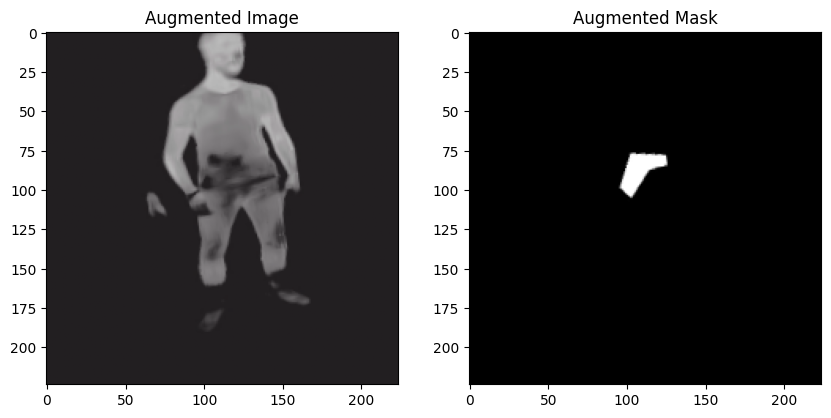

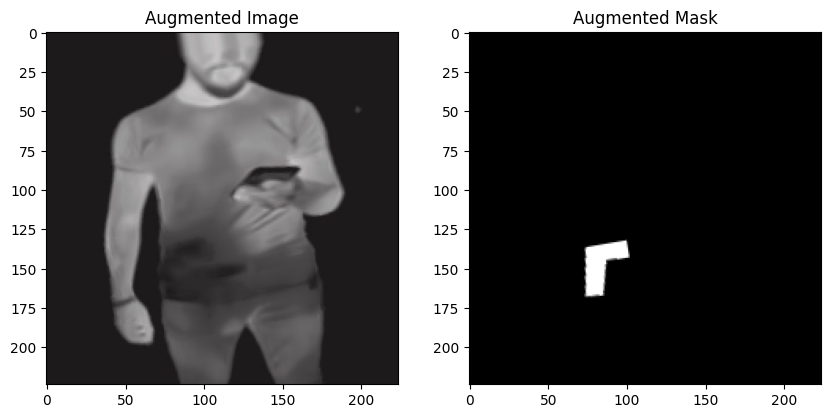

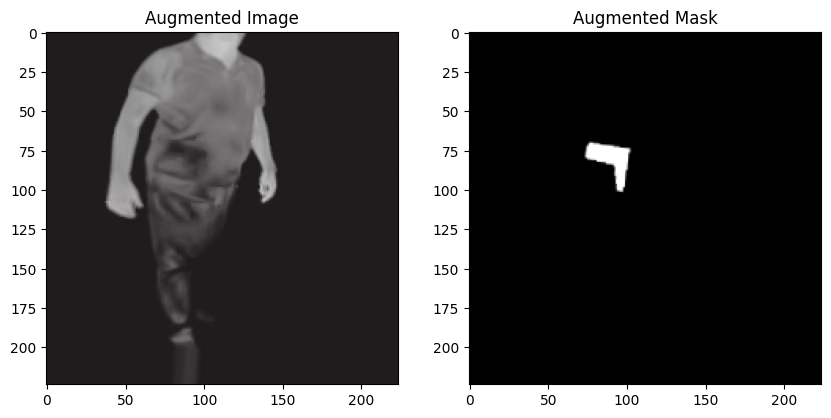

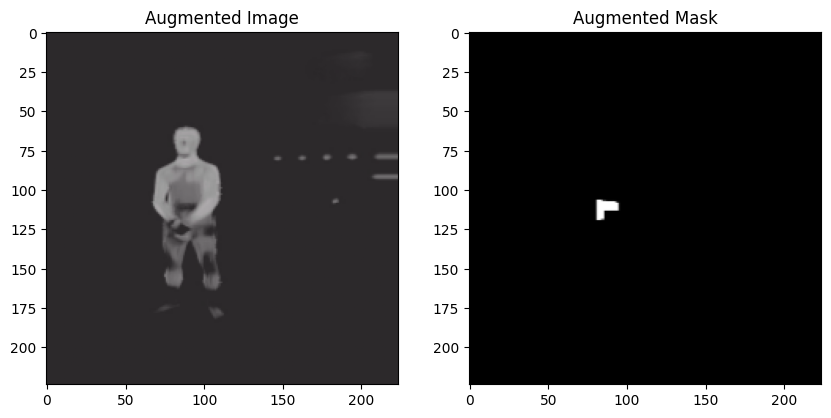

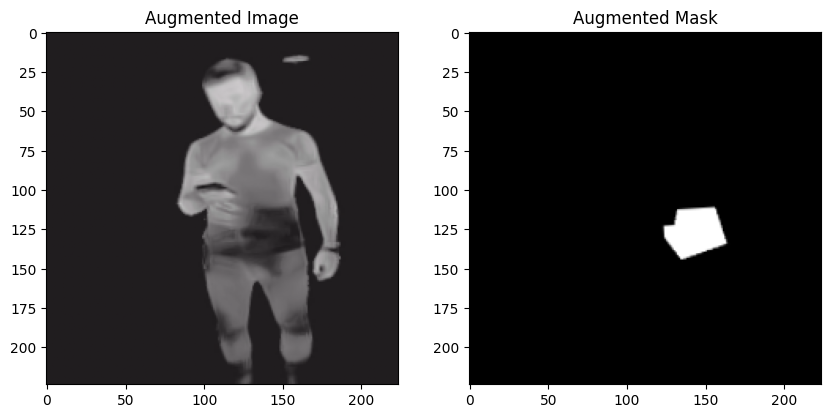

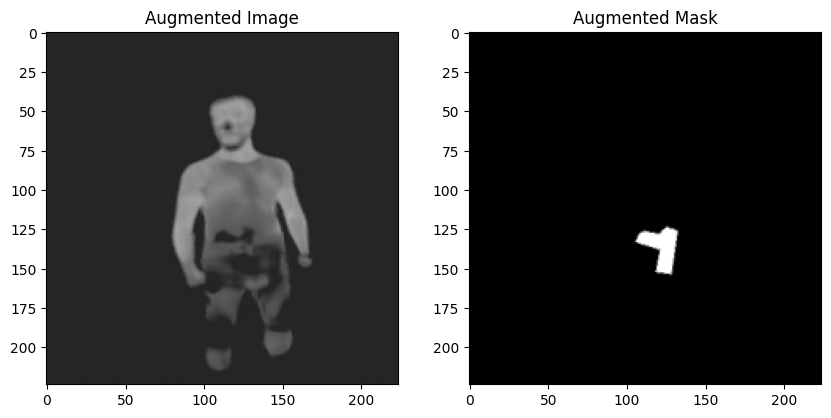

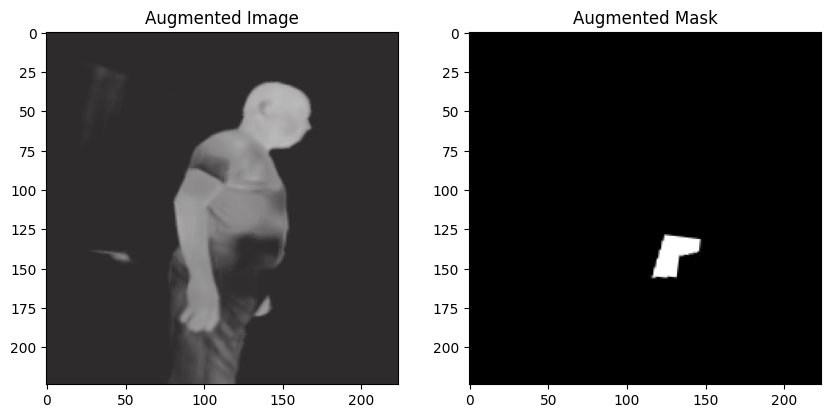

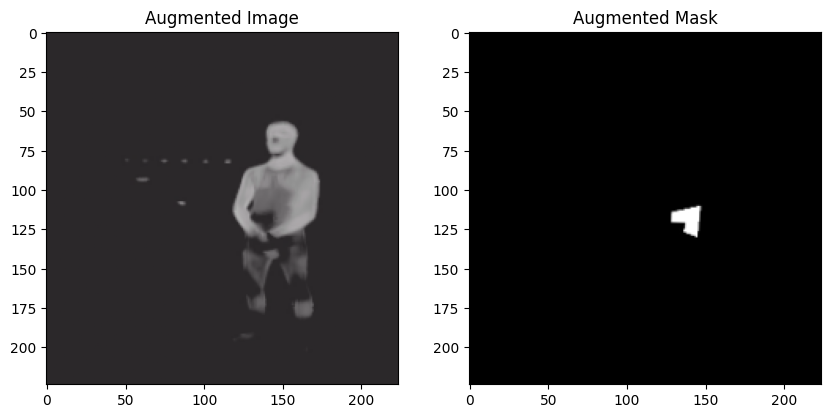

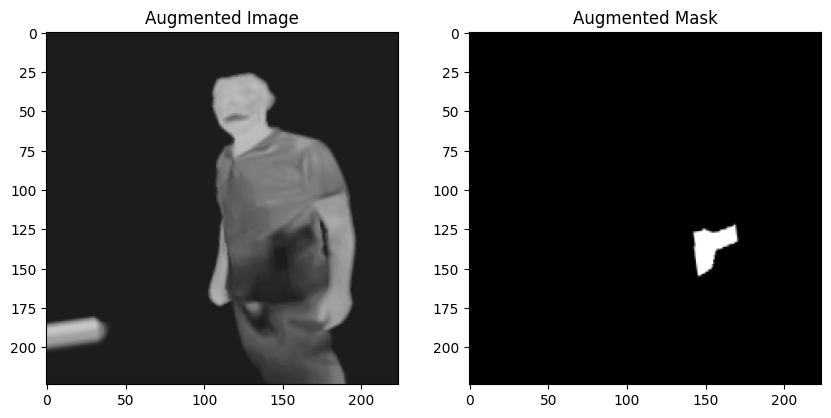

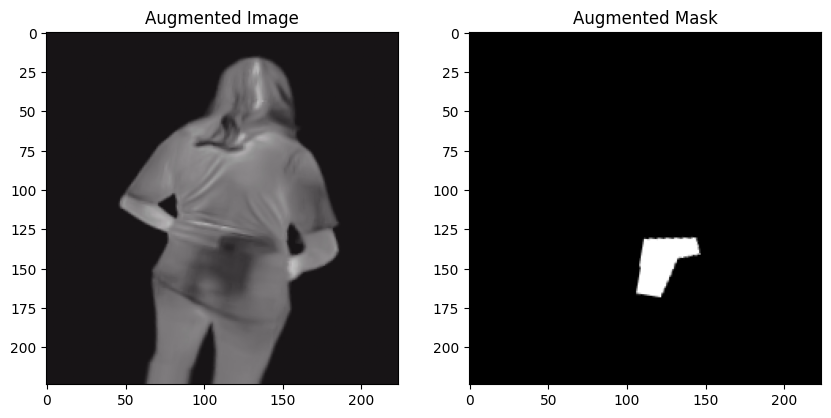

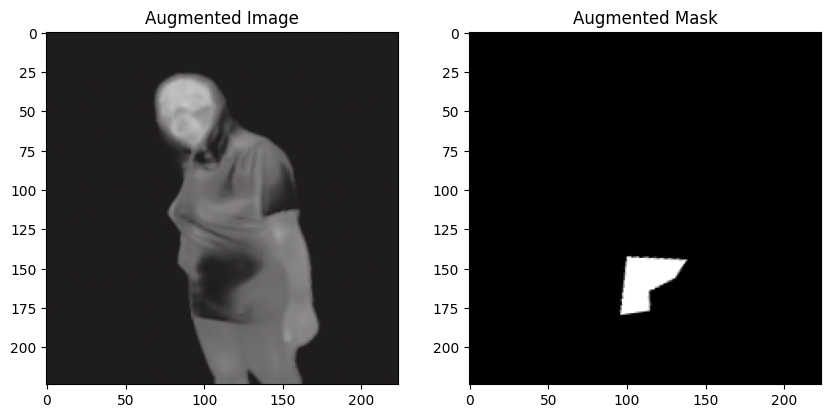

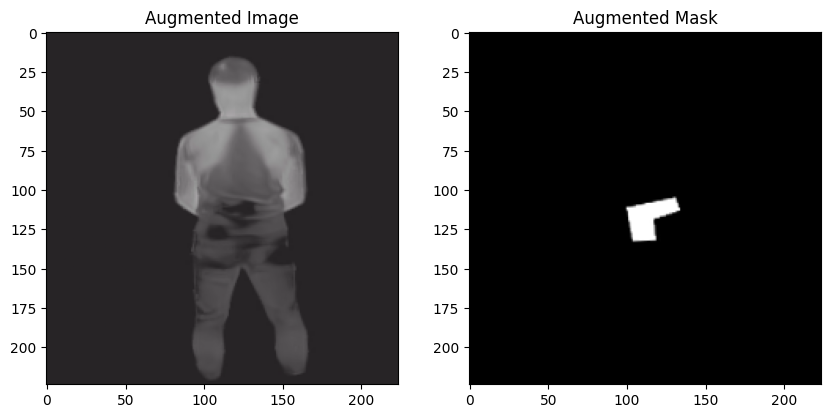

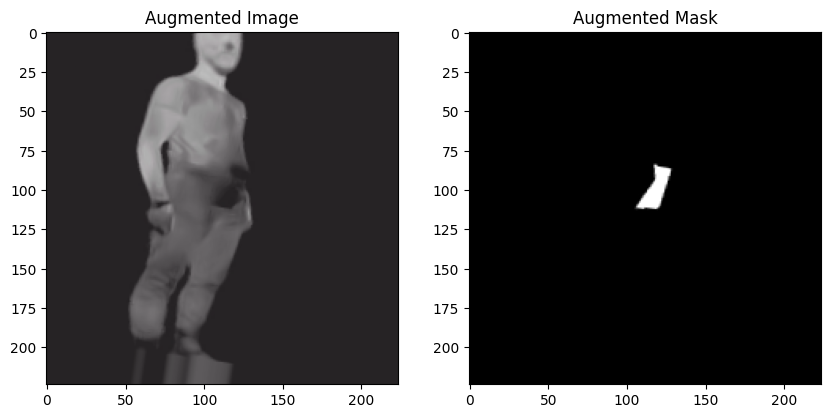

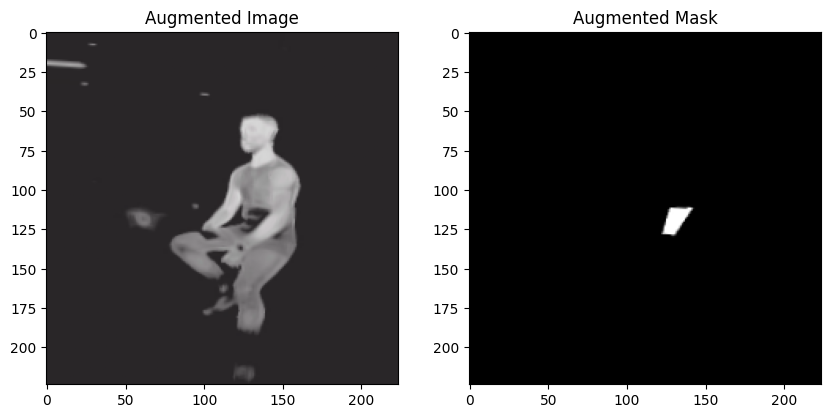

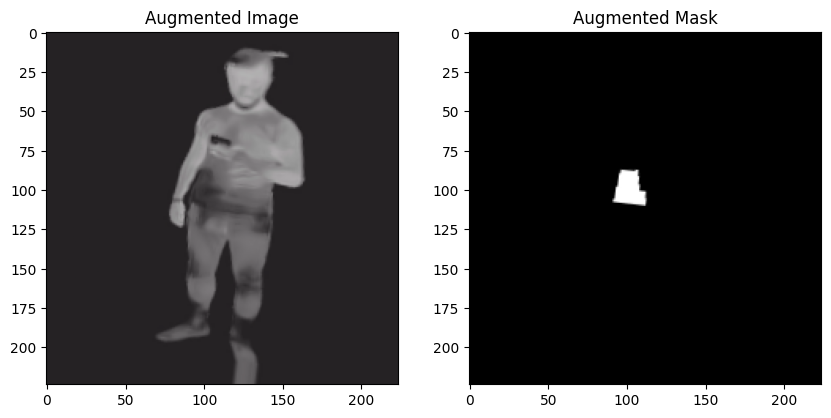

In [ ]:
# Display augmented images and masks
for i in range(5,20):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(X_train[i])
    plt.title('Augmented Image')

    plt.subplot(1, 2, 2)
    plt.imshow(y_train[i].squeeze(), cmap='gray')
    plt.title('Augmented Mask')

    plt.show()

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=44, shuffle=True)
print("Shape of X_trian:", X_train.shape)
print("Shape of y_trian:", y_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)

Shape of X_trian: (547, 224, 224, 3)
Shape of y_trian: (547, 224, 224, 1)
Shape of X_test: (35, 224, 224, 3)
Shape of y_test: (35, 224, 224, 1)


In [ ]:
# Define the UNet model architecture
def unet_model(input_shape):
    inputs = tf.keras.Input(shape=input_shape)

    # Encoder
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    # Decoder
    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(pool3)
    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv4)
    up1 = layers.UpSampling2D(size=(2, 2))(conv4)

    conv5 = layers.Conv2D(256, 2, activation='relu', padding='same')(up1)
    merge1 = layers.concatenate([conv3, conv5], axis=3)
    conv5 = layers.Conv2D(256, 3, activation='relu', padding='same')(merge1)
    conv5 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv5)
    up2 = layers.UpSampling2D(size=(2, 2))(conv5)

    conv6 = layers.Conv2D(128, 2, activation='relu', padding='same')(up2)
    merge2 = layers.concatenate([conv2, conv6], axis=3)
    conv6 = layers.Conv2D(128, 3, activation='relu', padding='same')(merge2)
    conv6 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv6)
    up3 = layers.UpSampling2D(size=(2, 2))(conv6)

    conv7 = layers.Conv2D(64, 2, activation='relu', padding='same')(up3)
    merge3 = layers.concatenate([conv1, conv7], axis=3)
    conv7 = layers.Conv2D(64, 3, activation='relu', padding='same')(merge3)
    conv7 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv7)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(conv7)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

In [ ]:
input_shape = (224, 224, 3)  # Adjusted input shape for RGB images
model = unet_model(input_shape)

In [ ]:
from sklearn.metrics import accuracy_score
import torch
from tensorflow.keras import backend as K

def dice_coefficient(y_true, y_pred, smooth=1):
    intersection = K.sum(K.abs(y_true * y_pred), axis=-1)
    union = K.sum(y_true, axis=-1) + K.sum(y_pred, axis=-1)
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice

def iou(y_true, y_pred, smooth=1):
    intersection = torch.sum(y_true * y_pred)
    union = torch.sum(y_true) + torch.sum(y_pred) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou
def mean_iou(y_true, y_pred, num_classes):
    m_iou = 0
    for cls in range(num_classes):
        intersection = np.sum((y_true == cls) & (y_pred == cls))
        union = np.sum((y_true == cls) | (y_pred == cls))
        iou_cls = intersection / union
        m_iou += iou_cls
    m_iou /= num_classes
    return m_iou

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Assuming num_classes is the number of classes for segmentation
num_classes = 2

In [ ]:
# Define the validation data
validation_data = (X_val, y_val)

# Fit the model using X_train and y_train
history = model.fit(
    X_train,  # Training input data
    y_train,  # Training target data
    epochs=3,
    batch_size=32,
    validation_data=validation_data  # Specify the validation data
)


Epoch 1/3
18/18 [==============================] - 2227s 123s/step - loss: 0.1159 - accuracy: 0.9311 - val_loss: 0.0023 - val_accuracy: 0.9877
Epoch 2/3
18/18 [==============================] - 2188s 122s/step - loss: 0.0017 - accuracy: 0.9883 - val_loss: 9.0893e-04 - val_accuracy: 0.9877
Epoch 3/3
18/18 [==============================] - 2215s 123s/step - loss: 5.6846e-04 - accuracy: 0.9883 - val_loss: 4.6746e-04 - val_accuracy: 0.9877


In [ ]:
y_pred = model.predict(X_test)

2/2 [==============================] - 37s 3s/step


In [ ]:
# Calculate metrics
m_iou = mean_iou(y_test, y_pred, num_classes=2)

print(f"Mean IoU: {m_iou}")

Dice coefficient: [[[0.99974436 0.9999981  0.9999999  ... 0.99999976 0.9999908  0.9992093 ]
  [0.999997   1.         1.         ... 1.         1.         0.9999832 ]
  [0.9999999  1.         1.         ... 1.         1.         0.9999988 ]
  ...
  [0.9999982  1.         1.         ... 1.         1.         0.99999404]
  [0.99993443 0.9999994  1.         ... 1.         0.99999964 0.99988043]
  [0.9976489  0.99989927 0.9999931  ... 0.9999976  0.999954   0.9969066 ]]

 [[0.99952257 0.9999949  0.99999964 ... 0.99999917 0.9999715  0.9984137 ]
  [0.99999225 1.         1.         ... 1.         0.9999999  0.9999505 ]
  [0.9999995  1.         1.         ... 1.         1.         0.99999523]
  ...
  [0.9999951  1.         1.         ... 1.         1.         0.99998057]
  [0.99986196 0.9999981  1.         ... 1.         0.99999857 0.9997086 ]
  [0.99626666 0.9997937  0.9999825  ... 0.99999154 0.9998784  0.9945827 ]]

 [[0.99971217 0.99999774 0.9999999  ... 0.99999976 0.99998856 0.99909854]
  [0

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# Print the test loss and accuracy
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 [==============================] - 36s 3s/step - loss: 0.1089 - accuracy: 0.9904
Test Loss: 0.10892053693532944
Test Accuracy: 0.9904462099075317


1/1 [==============================] - 1s 874ms/step


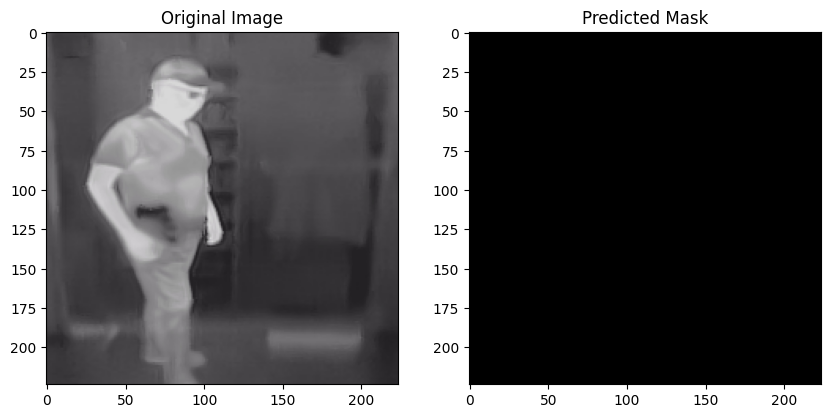

In [ ]:
from keras.preprocessing import image as keras_image
image = '/content/data/with gun/flir_20200423T222040 kopyala.jpg'
# Load the image using keras.preprocessing
img = keras_image.load_img(image, target_size=(224, 224))
img_array = keras_image.img_to_array(img)
img_array = img_array / 255.0  # Normalize the image

# Reshape the image array to match model input shape (if needed)
img_array = np.expand_dims(img_array, axis=0)

# Perform prediction using the UNet model
mask = model.predict(img_array)

# Threshold the mask (optional)
threshold = 0.5  # Adjust threshold as needed
binary_mask = np.where(mask > threshold, 1, 0)

# Display the original image and predicted mask
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(binary_mask[0, :, :, 0], cmap='gray')  # Assuming binary mask shape is (1, height, width, 1)
plt.title('Predicted Mask')

plt.show()